In [1]:
import pandas as pd
import numpy as np
import itertools
import warnings
import os

# Importamos SOLO PatchTST
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import MSE, MAE

warnings.filterwarnings('ignore')
print("✅ Librerías para PatchTST cargadas.")

d:\programas\tfm\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-09 13:44:48,366	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-02-09 13:44:48,569	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


✅ Librerías para PatchTST cargadas.


In [2]:
# 1. Cargar datos
filename = "dataset_tfm_56_survivors.csv"

if os.path.exists(filename):
    df = pd.read_csv(filename)
    df['ds'] = pd.to_datetime(df['ds'])

    # Configuración Caso 3
    VAL_YEAR = 2023
    
    # --- FILTRO DE SEGURIDAD ---
    # Usamos .size() para contar días y evitar errores de columnas
    counts = df.groupby('unique_id').size().reset_index(name='n_days')
    
    # 335 días = 60 input + 5 horizonte + ~260 validación + margen
    MIN_REQUIRED = 335 
    valid_ids = counts[counts['n_days'] > MIN_REQUIRED]['unique_id'].unique()
    
    df = df[df['unique_id'].isin(valid_ids)].copy()
    print(f"✅ Empresas aptas tras filtro: {df['unique_id'].nunique()}")

    # 2. Preprocesamiento
    df = df[(df['y'] <= 0.5) & (df['y'] >= -0.5)].copy()
    stats = df.groupby('unique_id')['y'].agg(['mean', 'std']).reset_index()
    df = pd.merge(df, stats, on='unique_id', how='left')
    df['y_norm'] = (df['y'] - df['mean']) / (df['std'] + 1e-8)

    # 3. DataFrame Final
    df_final = df.copy()
    df_final['y_raw'] = df_final['y']
    df_final['y'] = df_final['y_norm']
    df_final = df_final[['unique_id', 'ds', 'y', 'y_raw']].dropna()
    df_final = df_final.sort_values(by=['unique_id', 'ds']).reset_index(drop=True)

    # 4. Preparar variables
    df_input = df_final.copy()
    
    # Val Size Robusto
    df_2023 = df_input[df_input['ds'].dt.year == VAL_YEAR]
    if len(df_2023) > 0:
        val_size = int(df_2023.groupby('unique_id').size().median())
        print(f"✅ Datos listos. Validación: {val_size} días.")
    else:
        print("❌ ERROR: No hay datos en 2023.")
        val_size = 0

else:
    print(f"❌ ERROR: No se encuentra el archivo '{filename}'.")

✅ Empresas aptas tras filtro: 56
✅ Datos listos. Validación: 255 días.


In [3]:
def ejecutar_patchtst_final(param_grid, df_train, val_size):
    print(f"\n🚀 INICIANDO GRID SEARCH PARA PatchTST (Caso 3)")
    print(f"   📂 Archivo de salida: grid_search_PatchTST_case3.csv")
    
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    results = []
    HORIZONTE = 5
    INPUT_SIZE_FIJO = 60

    for i, params in enumerate(combinations):
        
        # --- REGLA DE ORO TRANSFORMER ---
        # hidden_size debe ser divisible por n_heads. Si no, saltamos.
        if params['hidden_size'] % params['n_heads'] != 0:
            # print(f"   ⚠️ Saltando configuración inválida: {params}")
            continue

        print(f"   ⚙️ Probando: {params} ...", end=" ")
        
        try:
            model = PatchTST(
                h=HORIZONTE,
                input_size=INPUT_SIZE_FIJO,
                loss=MSE(),
                valid_loss=MAE(),
                max_steps=300,
                scaler_type='identity',
                start_padding_enabled=True, # Seguridad anti-crash
                
                # PARÁMETROS PatchTST
                patch_len=params['patch_len'],       # Tamaño del trozo
                hidden_size=params['hidden_size'],   # Tamaño vector latente
                n_heads=params['n_heads'],           # Cabezales de atención
                encoder_layers=params['encoder_layers'], # Capas
                
                random_seed=42
            )
            
            nf = NeuralForecast(models=[model], freq='B')
            nf.fit(df=df_train, val_size=val_size)
            
            cutoff_date = f"{VAL_YEAR}-01-01"
            df_history = df_train[df_train['ds'] < cutoff_date].copy()
            forecasts = nf.predict(df=df_history).reset_index()
            
            combined = pd.merge(forecasts, df_train[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='inner')
            col_pred = 'PatchTST'
            mae = (combined['y'] - combined[col_pred]).abs().mean()
            
            # Robustez
            errors_per_id = combined.groupby('unique_id').apply(
                lambda x: (x['y'] - x[col_pred]).abs().mean()
            ).reset_index(name='MAE_Empresa')
            
            vol_data = []
            for uid in df_history['unique_id'].unique():
                series = df_history[df_history['unique_id']==uid]['y']
                v = series.tail(INPUT_SIZE_FIJO).std() if len(series) >= INPUT_SIZE_FIJO else 0
                vol_data.append({'unique_id': uid, 'Input_Vol': v})
            
            df_vol = pd.DataFrame(vol_data)
            analysis = pd.merge(df_vol, errors_per_id, on='unique_id')
            corr = analysis['Input_Vol'].corr(analysis['MAE_Empresa'])
            
            print(f"✅ MAE: {mae:.5f} | Corr: {corr:.4f}")
            
            res = params.copy()
            res['MAE'] = mae
            res['Correlacion'] = corr
            results.append(res)
            
        except Exception as e:
            print(f"❌ Error: {e}")

    if results:
        df_res = pd.DataFrame(results).sort_values('MAE')
        df_res.to_csv("grid_search_PatchTST_case3.csv", index=False)
        print(f"\n🏆 GANADOR PatchTST: MAE {df_res.iloc[0]['MAE']:.5f}")

In [ ]:
grid_patch_params = {
    'patch_len': [4, 8, 16],       # Añadido 4 (muy granular) para ver si trozos pequeños captan mejor la volatilidad
    'hidden_size': [64, 128, 256], # Añadido 256 para probar si más "cerebro" ayuda o provoca overfitting
    'n_heads': [4, 8, 16, 32],             # Añadido 8 cabezales (Divisible con 64, 128 y 256)
    'encoder_layers': [2, 3, 4]       # Añadido 3 capas para testear si más abstracción mejora el resultado
}
print("📋 Parámetros PatchTST listos (Grid Ampliado).")

📋 Parámetros PatchTST listos (Grid Ampliado).


In [ ]:
ejecutar_patchtst_final(grid_patch_params, df_input, val_size)

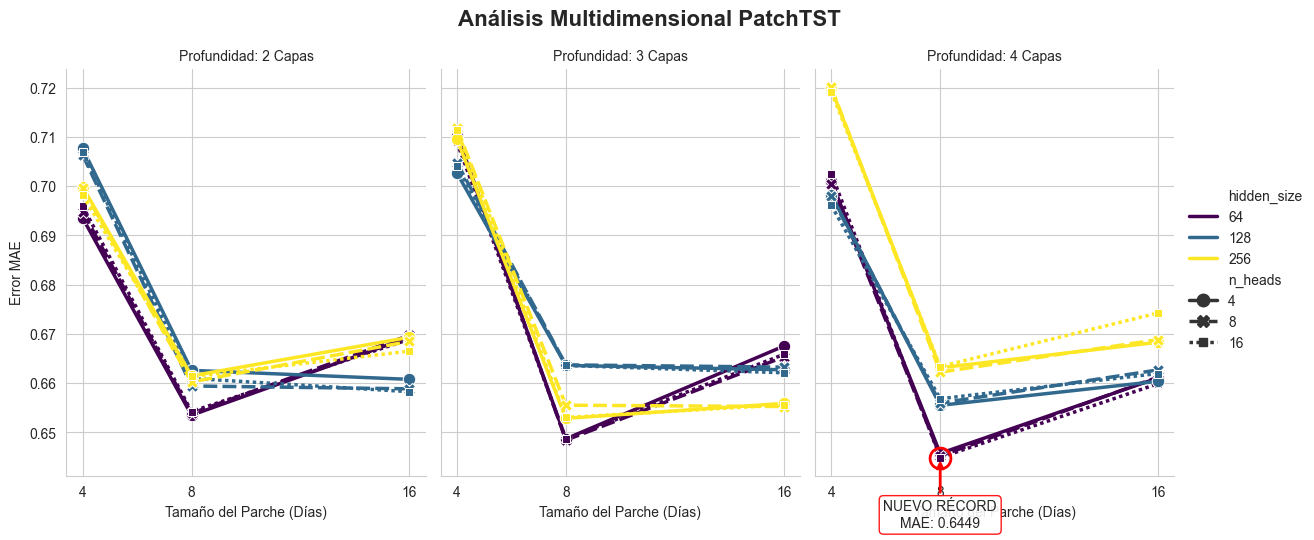

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# 1. CARGA DE DATOS (Incluyendo los resultados de 4 capas)
csv_data = """patch_len,hidden_size,n_heads,encoder_layers,MAE,Correlacion
8,64,16,4,0.6449001067431007,0.42912862009547936
8,64,8,4,0.6452135775024398,0.43007597398055936
8,64,4,4,0.6457517630106964,0.43083998365673376
8,64,8,3,0.6484349672157023,0.4584357704484251
8,64,16,3,0.6486734868761148,0.46182579272773877
8,64,4,3,0.6487033937086429,0.45917600484104304
8,256,4,3,0.6528593091223884,0.4986927769952952
8,256,16,3,0.6530458625799967,0.4995824448038295
8,64,4,2,0.6534990529156208,0.4634904855033463
8,64,8,2,0.6538886715674715,0.4697010879303336
8,64,16,2,0.6542456517230507,0.4658932254700515
16,256,8,3,0.6552620793751809,0.47775090427090255
8,128,4,4,0.6554988516954399,0.44499602517840536
8,256,8,3,0.6555301656624376,0.4993260890097657
16,256,16,3,0.6555956002148963,0.47777732007824986
16,256,4,3,0.6558984996042875,0.4854184368287713
8,128,8,4,0.6559596487603794,0.4434578798129609
8,128,16,4,0.6568432634478487,0.45059339808178267
16,128,16,2,0.6582707763919575,0.420750560617107
16,128,8,2,0.6588582841741621,0.4201762124103193
8,128,8,2,0.6594306738712844,0.46908217190198276
16,64,16,4,0.6598942804221847,0.47860408337945404
8,256,8,2,0.6602612939522841,0.446404896615586
16,128,4,4,0.6603949327304147,0.44538611354445445
16,128,4,2,0.660778323718325,0.4179186384986791
8,128,16,2,0.660977237803055,0.46727172178282367
16,64,4,4,0.6610723306445402,0.47735611403610495
16,64,8,4,0.6612382067022043,0.4774269088345294
8,256,16,2,0.6613611789138242,0.4409071693744436
8,256,4,2,0.661485656571004,0.4470784184373483
16,128,16,4,0.6619668169466029,0.4506684645149829
16,128,16,3,0.6621136697712574,0.4711149889448479
8,256,8,4,0.6622397250277501,0.46185303703059905
8,128,4,2,0.6626078594553437,0.4684992338118217
16,128,8,4,0.66269594912372,0.44981488646004797
16,128,4,3,0.6627211490539688,0.4694805244875273
8,256,4,4,0.663125637991496,0.45993630348323106
16,128,8,3,0.6632646360951929,0.46892534525372914
8,256,16,4,0.6633784172025898,0.4616718041886628
8,128,16,3,0.6636013150505905,0.43752035225162034
8,128,4,3,0.6636162107107052,0.4405633466485066
8,128,8,3,0.6637164993190162,0.43863497773616317
16,64,8,3,0.6653200679651636,0.4559010328352808
16,64,16,3,0.6658379742127369,0.4572942223966041
16,256,16,2,0.6665089754871871,0.4613699319650721
16,64,4,3,0.6675201785899011,0.45440416097657116
16,256,4,4,0.6683161972606245,0.4276515867006437
16,256,8,2,0.6684885720081912,0.4602764111578308
16,256,8,4,0.6688578965309887,0.4363597552324792
16,64,16,2,0.6689187620914083,0.475357061429446
16,256,4,2,0.669319851841006,0.4607797839222174
16,64,4,2,0.6693405118077095,0.4728330056421389
16,64,8,2,0.6697258690724109,0.47339770190825264
16,256,16,4,0.6742559707841184,0.4463775999899283
4,64,4,2,0.6935492679376773,0.40596210603212973
4,64,8,2,0.6948628897279587,0.4077332516500794
4,64,16,2,0.6959694612006078,0.41080849613444365
4,128,16,4,0.6961174942227002,0.40468087529275865
4,128,8,4,0.6979203681987649,0.41118067935557256
4,256,16,2,0.6981887399512451,0.4066889812365697
4,128,4,4,0.6982638805969514,0.4086087969822077
4,256,8,2,0.6995631103103467,0.4071616420472374
4,256,4,2,0.6998580019435992,0.4128460141556148
4,64,8,4,0.7003720831919532,0.39028890749149864
4,64,4,4,0.7009991952670762,0.3896404044086367
4,64,16,4,0.7025704935572316,0.3918226466657434
4,128,4,3,0.7026634925084715,0.39373206467934485
4,128,16,3,0.7041298650927534,0.3968748407985433
4,128,8,3,0.7047777759400644,0.39511750312544125
4,128,8,2,0.7063641110468449,0.4034816304859427
4,128,16,2,0.7069379703456329,0.4038949035530312
4,128,4,2,0.7076843937858999,0.4005708488761467
4,64,16,3,0.7088936702549515,0.3986568439810735
4,256,4,3,0.7095210187722604,0.38514110174637295
4,64,4,3,0.7101558857888433,0.4039971094686459
4,64,8,3,0.7105332489616767,0.4016277408171608
4,256,16,3,0.7114836054866159,0.379280690397988
4,256,8,3,0.7117389193010363,0.3763835817899238
4,256,16,4,0.7191870545736148,0.40285337784559316
4,256,4,4,0.719805670982906,0.39743256116129644
4,256,8,4,0.7201022824827541,0.39565231675744494
"""
df_results = pd.read_csv(StringIO(csv_data))

# 2. CONFIGURACIÓN DEL GRÁFICO (FACET GRID)
sns.set_style("whitegrid")

# Creamos 3 columnas: una para cada profundidad (2, 3 y 4 capas)
g = sns.relplot(
    data=df_results,
    x='patch_len',
    y='MAE',
    col='encoder_layers',    # Divide en 3 subgráficos
    hue='hidden_size',       # Color según capacidad
    style='n_heads',         # Forma según cabezales
    kind='line',
    markers=True,
    palette='viridis',
    height=5, 
    aspect=0.8,              # Un poco más estrechos para que quepan bien
    linewidth=2.5,
    markersize=9
)

# 3. PERSONALIZACIÓN
g.fig.suptitle('Análisis Multidimensional PatchTST', 
               fontsize=16, fontweight='bold', y=1.05)
g.set_axis_labels("Tamaño del Parche (Días)", "Error MAE")
g.set_titles("Profundidad: {col_name} Capas")

# Ajustar ejes X para mostrar solo los valores probados
for ax in g.axes.flat:
    ax.set_xticks([4, 8, 16])

# Destacar el GANADOR ABSOLUTO (Ahora en el panel de 4 capas, índice 2)
# El ganador es Patch=8 con MAE 0.6449
ax_best = g.axes[0, 2] 
best_mae = df_results['MAE'].min()

ax_best.annotate(
    f"NUEVO RÉCORD\nMAE: {best_mae:.4f}",
    xy=(8, best_mae),
    xytext=(0, -50), textcoords='offset points',
    ha='center',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.9),
    arrowprops=dict(arrowstyle="->", color='red', linewidth=2)
)
# Círculo rojo sobre el ganador
ax_best.plot(8, best_mae, 'o', ms=15, mfc='none', mec='red', mew=2)

plt.savefig('grid_search_patchtst_4D_final.png', dpi=300, bbox_inches='tight')
plt.show()